In [49]:
!pip install -q tensorflow

In [50]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [51]:
# Load and preprocess MNIST
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5  # Normalize to [-1, 1]
x_train = np.expand_dims(x_train, axis=-1)
y_train = y_train.astype(np.int32)

BUFFER_SIZE = 60000
BATCH_SIZE = 128
LATENT_DIM = 100
NUM_CLASSES = 10

# Conditional embedding dimension
EMBED_DIM = 50

In [52]:
# Create tf.data pipeline
dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

In [53]:
# Generator model
def build_generator():
    noise = layers.Input(shape=(LATENT_DIM,))
    label = layers.Input(shape=(1,), dtype='int32')
    label_embedding = layers.Embedding(NUM_CLASSES, EMBED_DIM)(label)
    label_embedding = layers.Flatten()(label_embedding)

    model_input = layers.Concatenate()([noise, label_embedding])
    x = layers.Dense(7 * 7 * 256, use_bias=False)(model_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((7, 7, 256))(x)

    x = layers.Conv2DTranspose(128, 5, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(1, 5, strides=2, padding='same', activation='tanh')(x)
    return tf.keras.Model([noise, label], x)

In [54]:
# Discriminator model
def build_discriminator():
    img = layers.Input(shape=(28, 28, 1))
    label = layers.Input(shape=(1,), dtype='int32')

    label_embedding = layers.Embedding(NUM_CLASSES, 28 * 28)(label)
    label_embedding = layers.Reshape((28, 28, 1))(label_embedding)

    x = layers.Concatenate()([img, label_embedding])
    x = layers.Conv2D(64, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1)(x)
    return tf.keras.Model([img, label], x)

In [55]:
# Loss functions
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Initialize models
generator = build_generator()
discriminator = build_discriminator()

# Optimizers
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [56]:
# Training loop
@tf.function
def train_step(images, labels):
    current_batch_size = tf.shape(images)[0]
    noise = tf.random.normal([current_batch_size, LATENT_DIM])  # Use dynamic batch size

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator([noise, labels], training=True)

        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [57]:
# Training function
def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch, label_batch in dataset:
            train_step(image_batch, label_batch)

        print(f"Epoch {epoch + 1} completed")


In [58]:
# Start training
train(dataset, epochs=100)

Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Epoch 21 completed
Epoch 22 completed
Epoch 23 completed
Epoch 24 completed
Epoch 25 completed
Epoch 26 completed
Epoch 27 completed
Epoch 28 completed
Epoch 29 completed
Epoch 30 completed
Epoch 31 completed
Epoch 32 completed
Epoch 33 completed
Epoch 34 completed
Epoch 35 completed
Epoch 36 completed
Epoch 37 completed
Epoch 38 completed
Epoch 39 completed
Epoch 40 completed
Epoch 41 completed
Epoch 42 completed
Epoch 43 completed
Epoch 44 completed
Epoch 45 completed
Epoch 46 completed
Epoch 47 completed
Epoch 48 completed
Epoch 49 completed
Epoch 50 completed
Epoch 51 completed
Epoch 52 completed
Epoch 53 completed
Ep

In [59]:
def change_colors(image):
    image_colored = np.zeros((28, 28, 3))  # RGB image
    image_colored[:, :, 0] = 128
    image_colored[:, :, 1] = 0
    image_colored[:, :, 2] = 128

    # Apply yellow background (RGB: 255, 255, 0)
    image_colored[:, :, 0] = np.where(image > 0.5, 128, 255)
    image_colored[:, :, 1] = np.where(image > 0.5, 0, 255)
    image_colored[:, :, 2] = np.where(image > 0.5, 128, 0)

    return image_colored


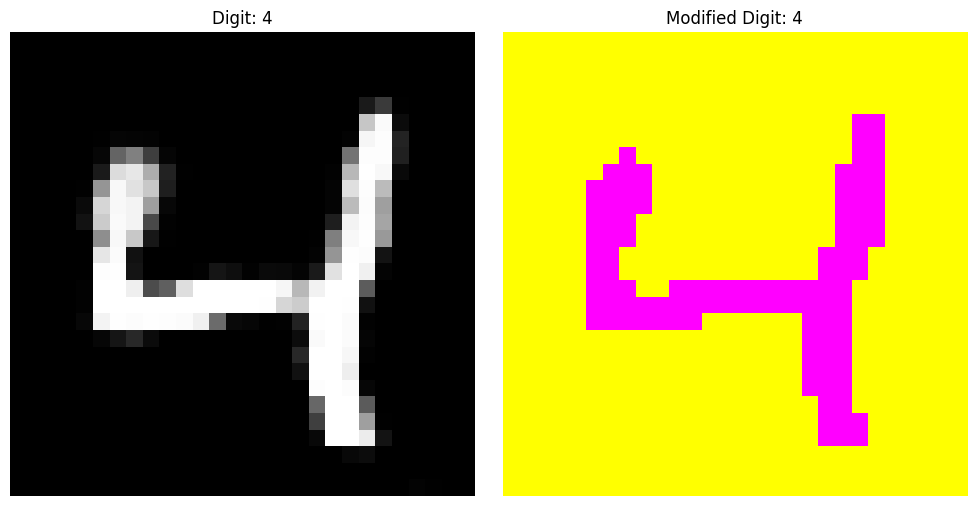

In [69]:
import matplotlib.pyplot as plt
import tensorflow as tf

def generate_digit(digit):
    # Generate noise vector
    noise = tf.random.normal([1, LATENT_DIM])

    # One-hot encoded label (assuming a single digit)
    label = tf.constant([[digit]])

    # Generate the image from the noise and label
    generated_image = generator([noise, label], training=False)

    # Normalize the image to [0, 1]
    img = (generated_image[0, :, :, 0] + 1) / 2.0

    # Apply color transformation (assuming `change_colors` is defined elsewhere)
    colored_image = change_colors(img)

    # Plot the original grayscale image and the colored image side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Plot original grayscale image
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f"Digit: {digit}")
    axes[0].axis('off')

    # Plot the modified colored image
    axes[1].imshow(colored_image)
    axes[1].set_title(f"Modified Digit: {digit}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to generate and plot digit 3
generate_digit(4)


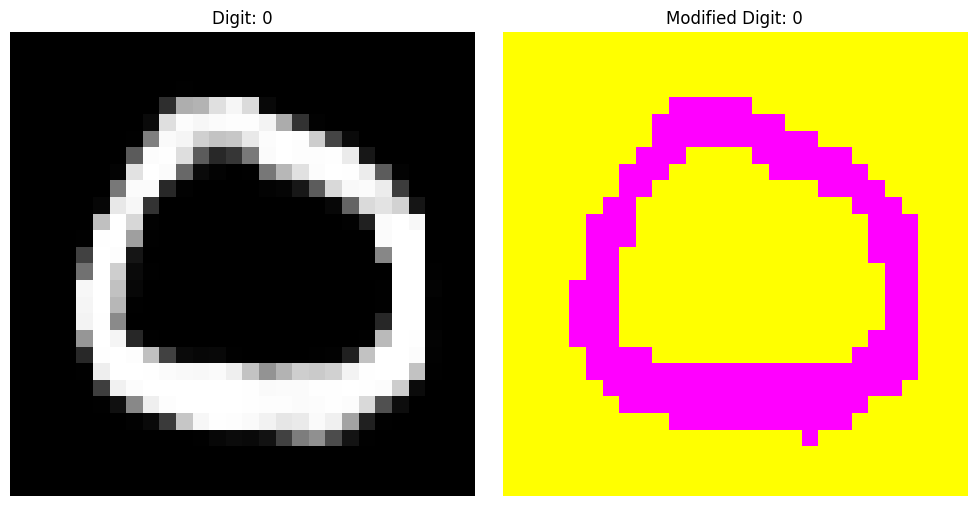

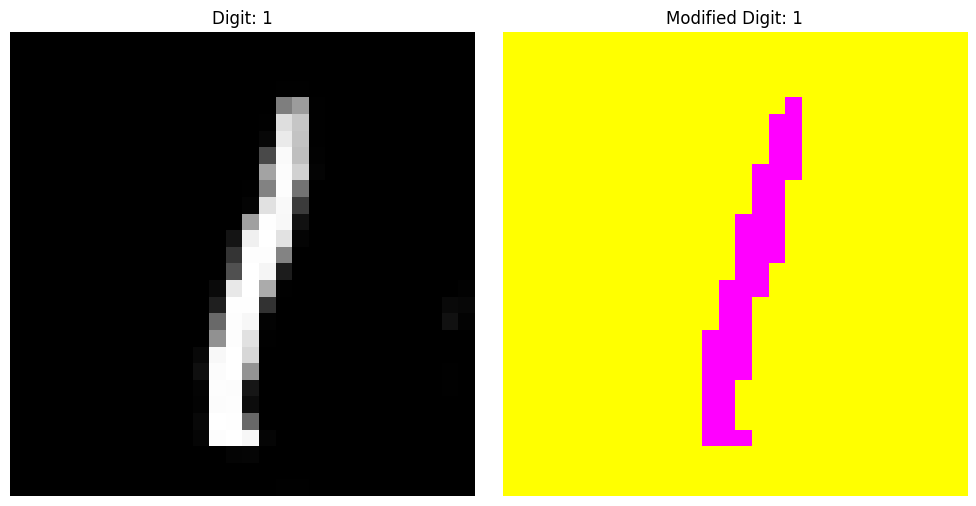

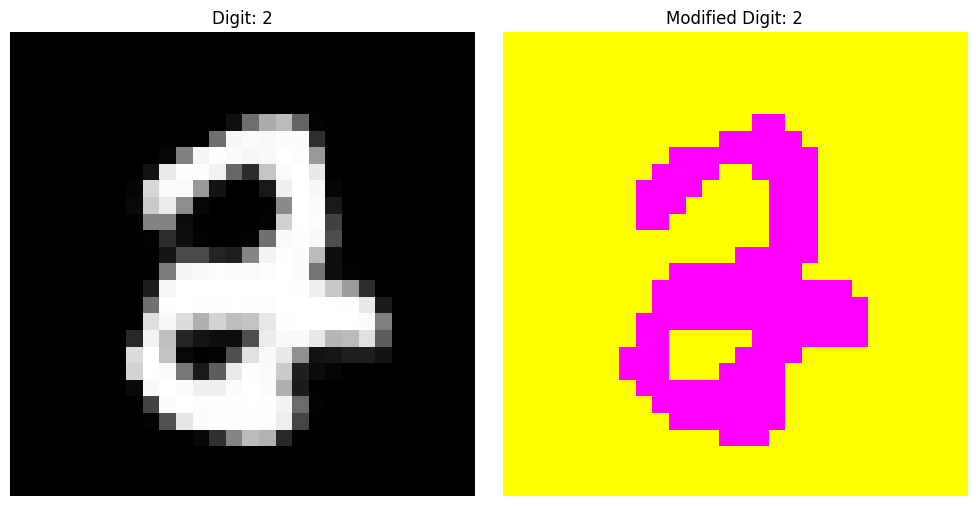

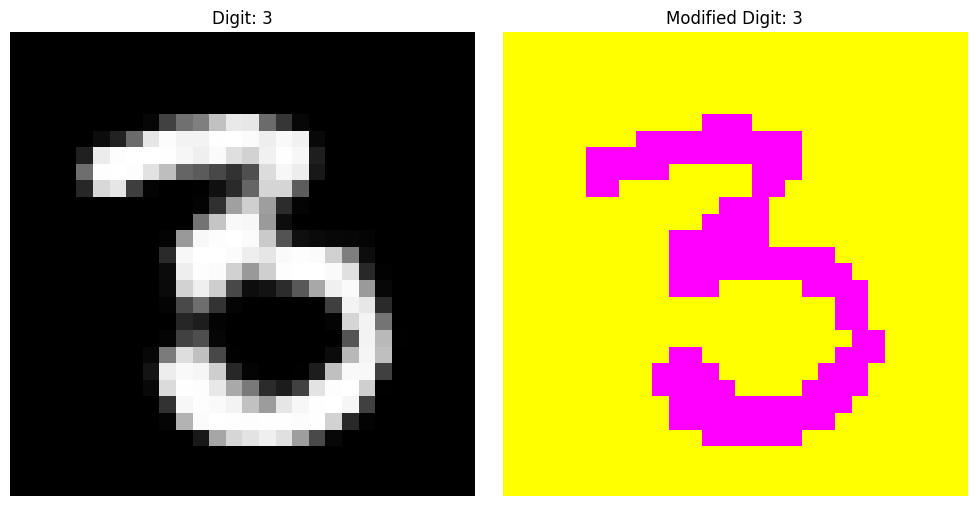

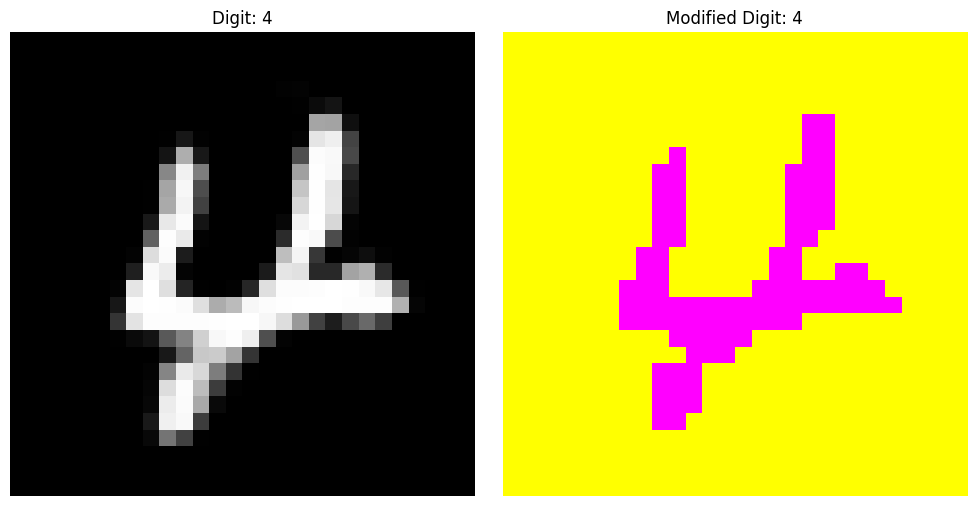

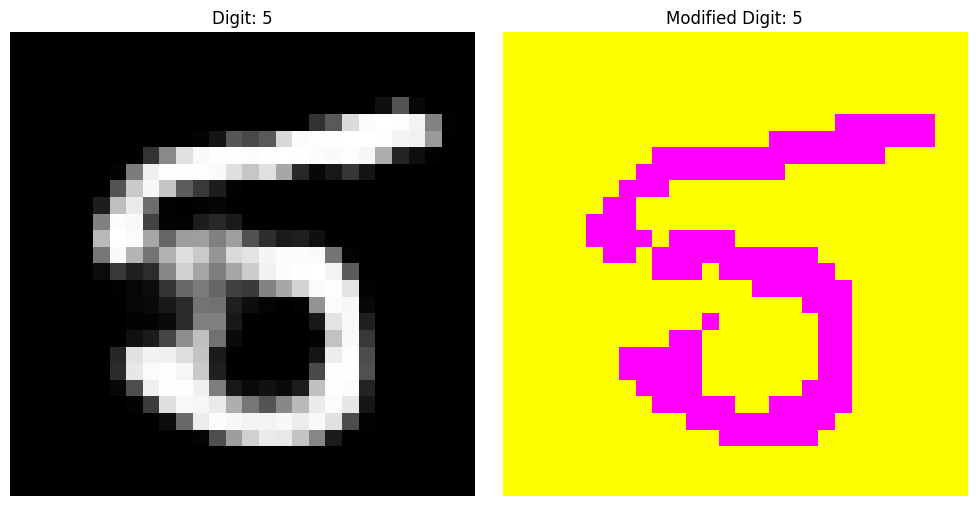

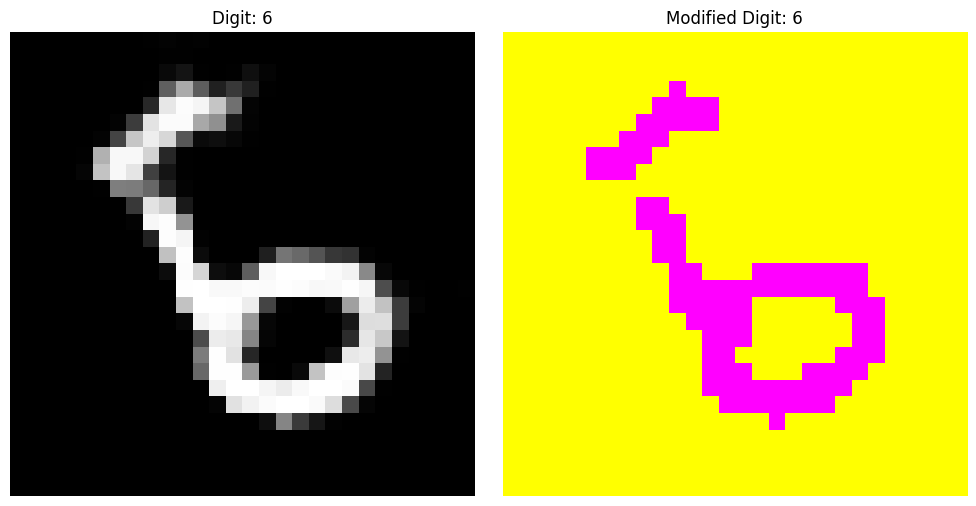

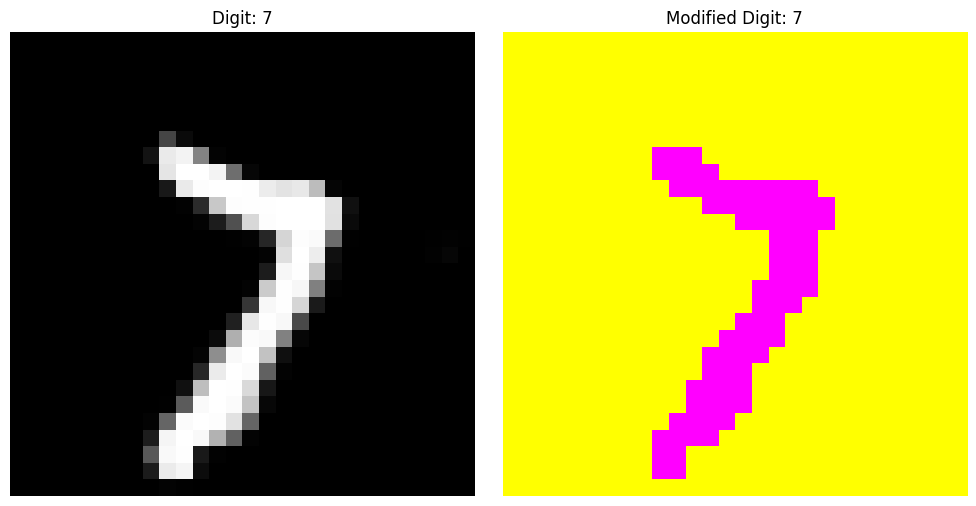

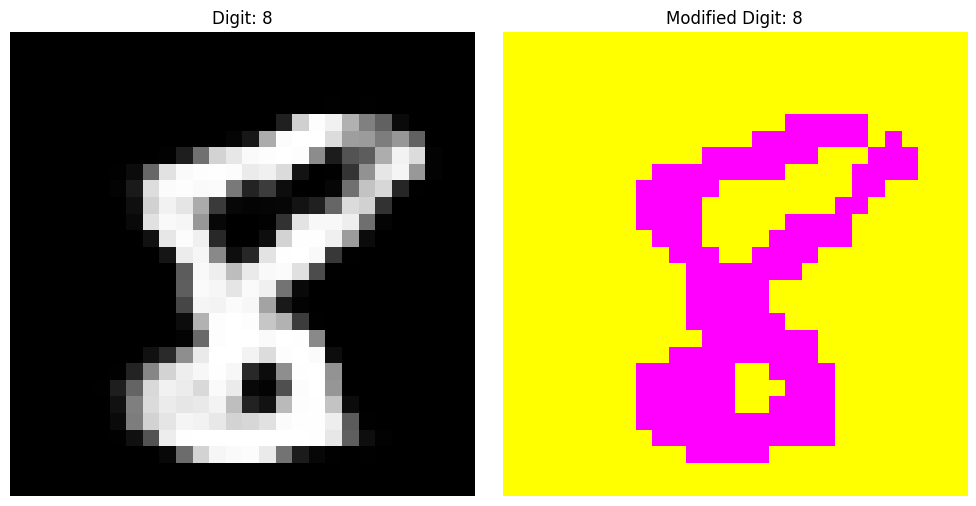

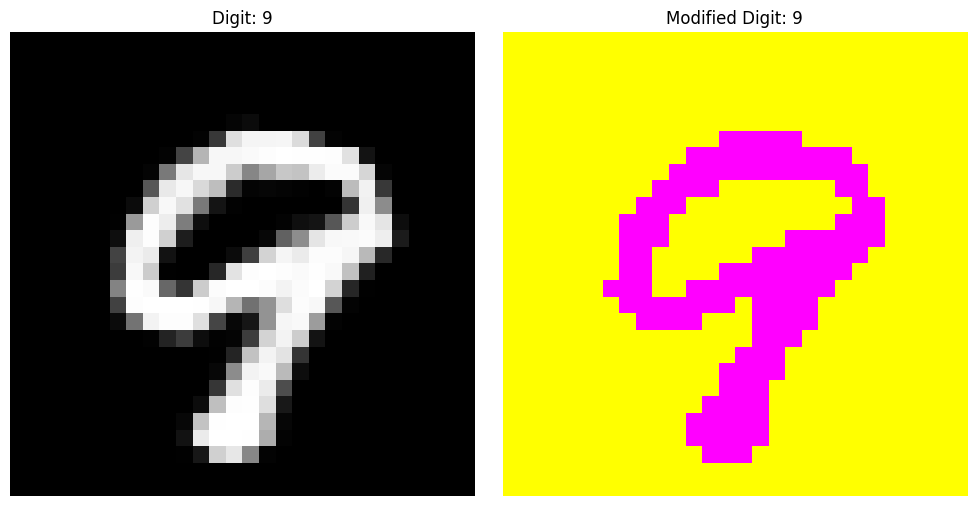

In [67]:
for i in range(0,10):
  generate_digit(i)